# Study 787 — Heatwave-Utilities 🌡️

*For the curious.* The dog-days of summer bake the country, air conditioners run flat out, and electricity demand hits its annual peak. Surely the **utilities** sector — the companies selling all that power — rallies through the heat? We put 27 summers (1999→2025) on the stand and asked the tape one plain question: **does XLU beat the market across the peak-heat weeks?** The answer is a polite *no*.

## The claim, and why it's a clean test

Peak US heat is **calendar-known**: because of the ~4-5 week *seasonal temperature lag*, the hottest average temperatures land in mid-to-late July, not on the June solstice (NOAA/NWS). So we anchor every year on a fixed **July 22** and hold XLU across the peak-heat window — zero look-ahead. We measure XLU's **abnormal** return (XLU − SPY, total-return) so we're not just measuring a summer that was good for *everything*.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from heatwave_utilities import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching XLU + SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} summers resolved")


panel loaded; 27 of 27 summers resolved


## The peak-heat calendar we test (fixed July-22 climatological centre)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['year', 'peak_heat_anchor'])

,year,peak_heat_anchor
0,1999,1999-07-22
1,2000,2000-07-22
2,2001,2001-07-22
3,2002,2002-07-22
4,2003,2003-07-22
5,2004,2004-07-22
6,2005,2005-07-22
7,2006,2006-07-22
8,2007,2007-07-22
9,2008,2008-07-22


## The picture: mean cumulative abnormal return around the peak

Offset 0 is the July-22 peak-heat anchor. Left of zero is the *ramp into* the heat; right of zero is the *through / past-peak* window (late July into August).

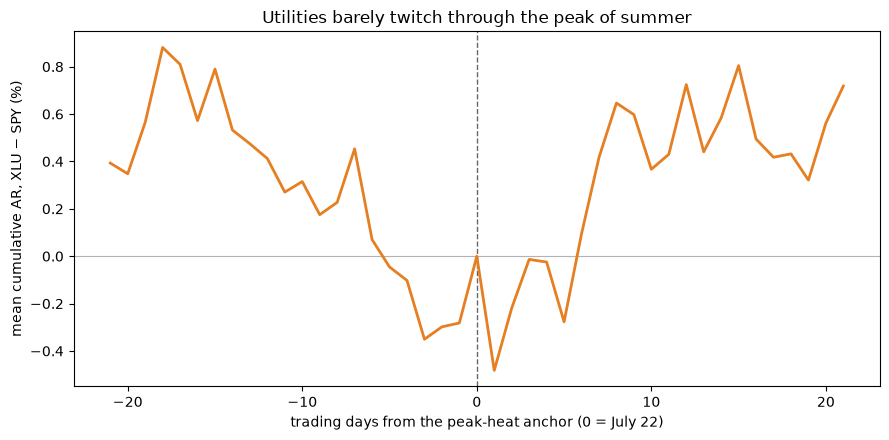

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#e67e22', lw=2)
ax.set_xlabel('trading days from the peak-heat anchor (0 = July 22)')
ax.set_ylabel('mean cumulative AR, XLU − SPY (%)')
ax.set_title('Utilities barely twitch through the peak of summer')
plt.tight_layout(); plt.show()

## The numbers

| window | mean AR | *t* | hit rate |
|---|--:|--:|--:|
| 2-week into-heat | -0.22% | -0.41 | 13/27 |
| 1-month into-heat | -0.19% | -0.33 | 15/27 |
| 2-week past-peak | +0.37% | +0.56 | 14/27 |
| 1-month past-peak | **+0.72%** | **+0.81** | 14/27 |

The 'rally through the heat' window is *directionally* right — XLU beats SPY by a whisker in the late-July-into-August month (+0.72%) — but the *t* is only +0.81 and the hit rate is a coin-flip 14/27. That's noise, not a season.

In [4]:
rows = [('2wk into-heat','pre_s'),('1mo into-heat','pre_l'),('2wk past-peak','post_s'),('1mo past-peak','post_l')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<14s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  hit {hr["k"]}/{hr["n"]}')

2wk into-heat  n=27  mean=-0.216%  t=-0.410  hit 13/27
1mo into-heat  n=27  mean=-0.194%  t=-0.331  hit 15/27
2wk past-peak  n=27  mean=+0.367%  t=+0.559  hit 14/27
1mo past-peak  n=27  mean=+0.718%  t=+0.814  hit 14/27


## So what?

The 'hold utilities through the dog-days' trade is folklore. Yes, summer heat spikes electricity *load* — but regulated rates, fuel pass-throughs and an efficient market mean that well-known demand pattern never shows up as a tradable *stock* edge. The best window is +0.72% with *t* < 1 and dies the moment you charge costs. Verdict: **None signal, Mirage tradability.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control.